# exP03 第1.2节：变量构造（Python）

本Notebook完成以下变量构造：
- 因变量：`Lev = total_liabilities / total_assets`
- 核心解释变量：`NPR = net_profit / total_assets`
- 控制变量：`Size`、`Tang`、`Growth`、`NDTS`、`SOE`
- 选做变量：`Liq`
- 宏观变量：`m2_growth`（按年）

说明：`Growth` 严格按 `(stkcd, year)` 排序后，分组使用滞后一期总资产计算。

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)

RAW = Path('../data/raw')
CLEAN = Path('../data/clean')
CLEAN.mkdir(parents=True, exist_ok=True)

RAW

PosixPath('../data/raw')

In [14]:
def extract_year(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors='coerce').dt.year

bs = pd.read_csv(RAW / 'balance_sheet.csv', dtype={'Stkcd': str})
isf = pd.read_csv(RAW / 'income_stmt.csv', dtype={'Stkcd': str})
cf = pd.read_csv(RAW / 'cashflow.csv', dtype={'Stkcd': str})
own = pd.read_csv(RAW / 'ownership.csv', dtype={'Symbol': str})
m2 = pd.read_csv(RAW / 'm2.csv')
st = pd.read_csv(RAW / 'st.csv', header=None, names=['stkcd', 'never_st'], dtype={'stkcd': str})

bs = bs.rename(columns={
    'Stkcd': 'stkcd',
    'Accper': 'accper',
    '报表类型': 'report_type',
    '流动资产合计': 'current_assets',
    '固定资产净额': 'fixed_assets_net',
    '资产总计': 'total_assets',
    '流动负债合计': 'current_liabilities',
    '负债合计': 'total_liabilities'
})
bs['year'] = extract_year(bs['accper'])

isf = isf.rename(columns={
    'Stkcd': 'stkcd',
    'Accper': 'accper',
    'Typrep': 'report_type',
    '净利润': 'net_profit'
})
isf['year'] = extract_year(isf['accper'])

cf = cf.rename(columns={
    'Stkcd': 'stkcd',
    'Accper': 'accper',
    'Typrep': 'report_type',
    '折旧摊销': 'depr_amort'
})
cf['year'] = extract_year(cf['accper'])

own = own.rename(columns={
    'Symbol': 'stkcd',
    'EndDate': 'end_date',
    'EquityNatureID': 'equity_nature_id'
})
own['year'] = extract_year(own['end_date'])

m2 = m2.rename(columns={'统计期间': 'period', 'M2': 'm2'})
m2['year'] = pd.to_datetime(m2['period'], format='%Y-%m', errors='coerce').dt.year

for dfx in [bs, isf, cf]:
    dfx['report_type'] = dfx['report_type'].astype(str).str.strip()

bs = bs[(bs['report_type'] == 'A') & (pd.to_datetime(bs['accper'], errors='coerce').dt.month == 12)]
isf = isf[(isf['report_type'] == 'A') & (pd.to_datetime(isf['accper'], errors='coerce').dt.month == 12)]
cf = cf[(cf['report_type'] == 'A') & (pd.to_datetime(cf['accper'], errors='coerce').dt.month == 12)]

for name, dfx in [('bs', bs), ('isf', isf), ('cf', cf), ('own', own), ('m2', m2), ('st', st)]:
    print(name, dfx.shape)

bs (57879, 10)
isf (57879, 6)
cf (57966, 11)
own (55508, 5)
m2 (16, 3)
st (5717, 2)


In [15]:
# 合并公司-年度面板
panel = bs[['stkcd', 'year', 'current_assets', 'fixed_assets_net', 'total_assets', 'current_liabilities', 'total_liabilities']].copy()

panel = panel.merge(
    isf[['stkcd', 'year', 'net_profit']],
    on=['stkcd', 'year'],
    how='left',
    validate='one_to_one'
)

panel = panel.merge(
    cf[['stkcd', 'year', 'depr_amort']],
    on=['stkcd', 'year'],
    how='left',
    validate='one_to_one'
)

panel = panel.merge(
    own[['stkcd', 'year', 'equity_nature_id']],
    on=['stkcd', 'year'],
    how='left'
)

panel = panel.merge(st, on='stkcd', how='left')
panel = panel.merge(m2[['year', 'm2']], on='year', how='left')

panel = panel.sort_values(['stkcd', 'year']).reset_index(drop=True)
panel.head()

,stkcd,year,current_assets,fixed_assets_net,total_assets,current_liabilities,total_liabilities,net_profit,depr_amort,equity_nature_id,never_st,m2
0,000001,2010,NaN,2.392293e+09,7.272071e+11,NaN,6.940095e+11,6.283816e+09,4.924520e+08,3,1.0,72585.18
1,000001,2011,NaN,3.524265e+09,1.258177e+12,NaN,1.182796e+12,1.039049e+10,9.098600e+08,3,1.0,85159.09
2,000001,2012,0.0,3.536443e+09,1.606537e+12,0.0,1.521738e+12,1.351078e+10,1.256366e+09,3,1.0,97414.88
3,000001,2013,0.0,3.694000e+09,1.891741e+12,0.0,1.779660e+12,1.523100e+10,1.402000e+09,3,1.0,110652.50
4,000001,2014,0.0,3.812000e+09,2.186459e+12,0.0,2.055510e+12,1.980200e+10,1.591000e+09,3,1.0,122837.48


In [16]:
# 变量构造（1.2）
panel['Lev'] = panel['total_liabilities'] / panel['total_assets']
panel['NPR'] = panel['net_profit'] / panel['total_assets']
panel['Size'] = np.log(panel['total_assets'])
panel['Tang'] = panel['fixed_assets_net'] / panel['total_assets']

panel['lag_total_assets'] = panel.groupby('stkcd')['total_assets'].shift(1)
panel['Growth'] = (panel['total_assets'] - panel['lag_total_assets']) / panel['lag_total_assets']

panel['NDTS'] = panel['depr_amort'] / panel['total_assets']

# SOE映射：兼容字符/数值编码；1=国企，2/3/4=非国企，其余设为缺失
equity_code = pd.to_numeric(panel['equity_nature_id'], errors='coerce')
panel['SOE'] = np.where(
    equity_code == 1,
    1.0,
    np.where(equity_code.isin([2, 3, 4]), 0.0, np.nan)
)

# 选做变量
panel['Liq'] = panel['current_assets'] / panel['current_liabilities']

# 宏观变量：M2同比增速（百分比）
m2_year = panel[['year', 'm2']].drop_duplicates(subset=['year']).sort_values('year').copy()
m2_year['m2_growth'] = m2_year['m2'].pct_change() * 100

# 为避免重复运行产生 m2_growth_x/m2_growth_y，先清理历史列
old_m2_growth_cols = [c for c in panel.columns if str(c).startswith('m2_growth')]
if old_m2_growth_cols:
    panel = panel.drop(columns=old_m2_growth_cols)

panel = panel.merge(m2_year[['year', 'm2_growth']], on='year', how='left')

# ST标记：1=从未ST/PT，0=曾ST/PT
panel['never_st'] = panel['never_st'].astype('float')

panel[['stkcd', 'year', 'Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE', 'Liq', 'm2_growth', 'never_st']].head(10)

/opt/anaconda3/envs/panel_capital_structure/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,stkcd,year,Lev,NPR,Size,Tang,Growth,NDTS,SOE,Liq,m2_growth,never_st
0,000001,2010,0.954349,0.008641,27.312477,0.003290,NaN,0.000677,0.0,NaN,NaN,1.0
1,000001,2011,0.940087,0.008258,27.860685,0.002801,0.730149,0.000723,0.0,NaN,17.322971,1.0
2,000001,2012,0.947216,0.008410,28.105102,0.002201,0.276877,0.000782,0.0,NaN,14.391640,1.0
3,000001,2013,0.940752,0.008051,28.268519,0.001953,0.177527,0.000741,0.0,NaN,13.588910,1.0
4,000001,2014,0.940109,0.009057,28.413304,0.001743,0.155792,0.000728,0.0,NaN,11.011934,1.0
5,000001,2015,0.935584,0.008721,28.550167,0.001910,0.146671,0.000706,0.0,NaN,13.343102,1.0
6,000001,2016,0.931547,0.007652,28.713990,0.002816,0.178005,0.000654,0.0,NaN,11.333124,1.0
7,000001,2017,0.931644,0.007138,28.809206,0.002474,0.099897,0.000666,0.0,NaN,9.042746,1.0
8,000001,2018,0.929783,0.007260,28.860250,0.003188,0.052369,0.000721,0.0,NaN,8.076325,1.0
9,000001,2019,0.920544,0.007158,29.001966,0.002816,0.152249,0.001422,0.0,NaN,8.744771,1.0


In [17]:
# 基本质量检查
key_vars = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE', 'Liq', 'm2_growth']
missing_rate = panel[key_vars].isna().mean().sort_values(ascending=False).to_frame('missing_rate')
print('Missing rate by variable:')
print(missing_rate)

print('\nSOE coding check:')
print(panel[['equity_nature_id', 'SOE']].drop_duplicates().sort_values(['equity_nature_id', 'SOE']).head(10))

print('\nM2 growth years sample:')
print(panel[['year', 'm2', 'm2_growth']].drop_duplicates('year').sort_values('year').head(8))

Missing rate by variable:
           missing_rate
Growth         0.098136
SOE            0.090395
m2_growth      0.036490
Liq            0.018331
NDTS           0.000086
Tang           0.000069
Lev            0.000000
NPR            0.000000
Size           0.000000

SOE coding check:
      equity_nature_id  SOE
16                   1  1.0
116                1,2  NaN
44915            1,2,3  NaN
4860               1,3  NaN
35                   2  0.0
52                 2,3  NaN
0                    3  0.0
795                  4  0.0
86                 NaN  NaN

M2 growth years sample:
   year         m2  m2_growth
0  2010   72585.18        NaN
1  2011   85159.09  17.322971
2  2012   97414.88  14.391640
3  2013  110652.50  13.588910
4  2014  122837.48  11.011934
5  2015  139227.81  13.343102
6  2016  155006.67  11.333124
7  2017  169023.53   9.042746


In [18]:
output_cols = [
    'stkcd', 'year',
    'total_assets', 'total_liabilities', 'net_profit', 'fixed_assets_net', 'depr_amort',
    'current_assets', 'current_liabilities',
    'Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE', 'Liq',
    'm2', 'm2_growth', 'never_st'
]

panel_12 = panel[output_cols].copy()
panel_12.to_csv(CLEAN / 'panel_variables_1_2.csv', index=False, encoding='utf-8-sig')

print('Saved:', CLEAN / 'panel_variables_1_2.csv')
print('Shape:', panel_12.shape)
panel_12.head()

Saved: ../data/clean/panel_variables_1_2.csv
Shape: (57879, 20)


,stkcd,year,total_assets,total_liabilities,net_profit,fixed_assets_net,depr_amort,current_assets,current_liabilities,Lev,NPR,Size,Tang,Growth,NDTS,SOE,Liq,m2,m2_growth,never_st
0,000001,2010,7.272071e+11,6.940095e+11,6.283816e+09,2.392293e+09,4.924520e+08,NaN,NaN,0.954349,0.008641,27.312477,0.003290,NaN,0.000677,0.0,NaN,72585.18,NaN,1.0
1,000001,2011,1.258177e+12,1.182796e+12,1.039049e+10,3.524265e+09,9.098600e+08,NaN,NaN,0.940087,0.008258,27.860685,0.002801,0.730149,0.000723,0.0,NaN,85159.09,17.322971,1.0
2,000001,2012,1.606537e+12,1.521738e+12,1.351078e+10,3.536443e+09,1.256366e+09,0.0,0.0,0.947216,0.008410,28.105102,0.002201,0.276877,0.000782,0.0,NaN,97414.88,14.391640,1.0
3,000001,2013,1.891741e+12,1.779660e+12,1.523100e+10,3.694000e+09,1.402000e+09,0.0,0.0,0.940752,0.008051,28.268519,0.001953,0.177527,0.000741,0.0,NaN,110652.50,13.588910,1.0
4,000001,2014,2.186459e+12,2.055510e+12,1.980200e+10,3.812000e+09,1.591000e+09,0.0,0.0,0.940109,0.009057,28.413304,0.001743,0.155792,0.000728,0.0,NaN,122837.48,11.011934,1.0


## 1.3 样本筛选 与 1.4 行业分类处理

本节在 `panel` 基础上完成：
1. 按作业要求执行样本筛选并记录每一步样本量变化；
2. 构造行业分类变量 `ind_code`：
   - 制造业（C开头）使用2位行业代码（如 C27）；
   - 其他行业使用1位行业代码（如 A、B、D、E）；
   - 样本量小于30的制造业子行业合并为 `C_other`。

In [19]:
# 读取行业数据并合并到面板
industry = pd.read_csv(RAW / 'industry.csv', dtype={'Symbol': str})
industry = industry.rename(columns={
    'Symbol': 'stkcd',
    'EndDate': 'end_date',
    'IndustryNameD': 'industry_name_d',
    'IndustryCodeD': 'industry_code_d'
})
industry['year'] = extract_year(industry['end_date'])
industry['industry_code_d'] = industry['industry_code_d'].astype(str).str.strip().str.upper()

industry = industry[['stkcd', 'year', 'industry_name_d', 'industry_code_d']].drop_duplicates(subset=['stkcd', 'year'], keep='last')

panel_s = panel.merge(industry, on=['stkcd', 'year'], how='left')

def sample_stats(df: pd.DataFrame):
    return int(len(df)), int(df['stkcd'].nunique())

steps = []

n_obs, n_firm = sample_stats(panel_s)
steps.append({
    '筛选步骤': '初始样本',
    '剔除观测数': np.nan,
    '剩余观测数': n_obs,
    '剩余公司数': n_firm
})

# Step 1: 剔除金融保险（J开头）
before = panel_s.copy()
panel_s = panel_s[~panel_s['industry_code_d'].str.startswith('J', na=False)].copy()
removed = len(before) - len(panel_s)
n_obs, n_firm = sample_stats(panel_s)
steps.append({
    '筛选步骤': '剔除金融保险',
    '剔除观测数': int(removed),
    '剩余观测数': n_obs,
    '剩余公司数': n_firm
})

# Step 2: 剔除曾被 ST/PT 处理公司（never_st=1 才保留）
before = panel_s.copy()
panel_s = panel_s[panel_s['never_st'] == 1].copy()
removed = len(before) - len(panel_s)
n_obs, n_firm = sample_stats(panel_s)
steps.append({
    '筛选步骤': '剔除 ST/PT',
    '剔除观测数': int(removed),
    '剩余观测数': n_obs,
    '剩余公司数': n_firm
})

# Step 3: 剔除 Lev > 1
before = panel_s.copy()
panel_s = panel_s[(panel_s['Lev'] <= 1) | (panel_s['Lev'].isna())].copy()
removed = len(before) - len(panel_s)
n_obs, n_firm = sample_stats(panel_s)
steps.append({
    '筛选步骤': '剔除 Lev > 1',
    '剔除观测数': int(removed),
    '剩余观测数': n_obs,
    '剩余公司数': n_firm
})

# Step 4: 剔除关键变量缺失
key_required = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE', 'industry_code_d']
before = panel_s.copy()
panel_s = panel_s.dropna(subset=key_required).copy()
removed = len(before) - len(panel_s)
n_obs, n_firm = sample_stats(panel_s)
steps.append({
    '筛选步骤': '剔除缺失值',
    '剔除观测数': int(removed),
    '剩余观测数': n_obs,
    '剩余公司数': n_firm
})

# 最终样本
steps.append({
    '筛选步骤': '最终样本',
    '剔除观测数': 0,
    '剩余观测数': n_obs,
    '剩余公司数': n_firm
})

screening_table = pd.DataFrame(steps)
screening_table

,筛选步骤,剔除观测数,剩余观测数,剩余公司数
0,初始样本,NaN,57879,5680
1,剔除金融保险,1305.0,56574,5588
2,剔除 ST/PT,10727.0,45847,4738
3,剔除 Lev > 1,25.0,45822,4738
4,剔除缺失值,8584.0,37238,4513
5,最终样本,0.0,37238,4513


In [20]:
# 1.4 行业分类处理：构造 ind_code
code = panel_s['industry_code_d'].astype(str).str.strip().str.upper()
is_c = code.str.startswith('C', na=False)

# 制造业取2位代码（如 C27），其他行业取1位（如 A/B/D）
panel_s['ind_code_raw'] = np.where(is_c, code.str[:3], code.str[:1])

# 将样本量<30的制造业子行业合并到 C_other
c_counts = panel_s.loc[panel_s['ind_code_raw'].str.startswith('C', na=False), 'ind_code_raw'].value_counts()
small_c = c_counts[c_counts < 30].index
panel_s['ind_code'] = panel_s['ind_code_raw'].where(~panel_s['ind_code_raw'].isin(small_c), 'C_other')

# 输出检查
print('最终样本规模:', panel_s.shape)
print('ind_code 示例:')
print(panel_s[['industry_code_d', 'ind_code_raw', 'ind_code']].drop_duplicates().head(15))

print('\n行业分布（前20）:')
print(panel_s['ind_code'].value_counts().head(20))

# 保存结果
screening_table.to_csv(CLEAN / 'sample_screening_1_3.csv', index=False, encoding='utf-8-sig')
panel_s.to_csv(CLEAN / 'panel_filtered_1_4.csv', index=False, encoding='utf-8-sig')

print('\nSaved:', CLEAN / 'sample_screening_1_3.csv')
print('Saved:', CLEAN / 'panel_filtered_1_4.csv')

最终样本规模: (37238, 26)
ind_code 示例:
    industry_code_d ind_code_raw ind_code
17              K70            K        K
108             S91            S        S
154             C30          C30      C30
185             C39          C39      C39
225             C15          C15      C15
232             F51            F        F
271             G58            G        G
272             G55            G        G
313             F52            F        F
329             D44            D        D
417             E49            E        E
503             C33          C33      C33
603             C38          C38      C38
665             L71            L        L
666             L72            L        L

行业分布（前20）:
ind_code
C39    3930
I      2737
C38    2475
C27    2452
C26    2421
C35    2377
F      1734
C34    1562
C36    1371
G      1147
D      1109
K      1048
C30     992
C29     926
E       817
C33     795
B       677
C32     650
C40     568
N       559
Name: count, dtype: int64

Saved: 

## 1.5 异常值处理（Winsorize）

按年度（截面）对以下连续变量做双侧 1% Winsorize：
`Lev`、`NPR`、`Tang`、`Growth`、`NDTS`、`Liq`。

说明：`Size` 与 `SOE` 不进行 Winsorize。

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

winsor_vars = ['Lev', 'NPR', 'Tang', 'Growth', 'NDTS', 'Liq']

# 使用 1.3/1.4 筛选后的样本
panel_w = panel_s.copy()

def winsorize_by_year(df: pd.DataFrame, col: str, p_low: float = 0.01, p_high: float = 0.99) -> pd.Series:
    def _clip(group: pd.Series) -> pd.Series:
        q_low = group.quantile(p_low)
        q_high = group.quantile(p_high)
        return group.clip(lower=q_low, upper=q_high)
    return df.groupby('year')[col].transform(_clip)

for v in winsor_vars:
    panel_w[f'{v}_raw'] = panel_w[v]
    panel_w[v] = winsorize_by_year(panel_w, v, 0.01, 0.99)

# 生成变量处理前后对比摘要
summary_rows = []
for v in winsor_vars:
    pre = panel_w[f'{v}_raw']
    post = panel_w[v]
    summary_rows.append({
        '变量': v,
        'P1(处理前)': pre.quantile(0.01),
        'P99(处理前)': pre.quantile(0.99),
        'Min(处理后)': post.min(),
        'Max(处理后)': post.max()
    })

winsor_summary = pd.DataFrame(summary_rows)
winsor_summary

,变量,P1(处理前),P99(处理前),Min(处理后),Max(处理后)
0,Lev,0.054598,0.844929,0.032090,0.895716
1,NPR,-0.186578,0.191661,-0.339241,0.220089
2,Tang,0.002772,0.669399,0.002429,0.734079
3,Growth,-0.236681,1.563676,-0.309981,3.755898
4,NDTS,0.001411,0.077754,0.000788,0.092324
5,Liq,0.378202,15.845975,0.291406,26.264186


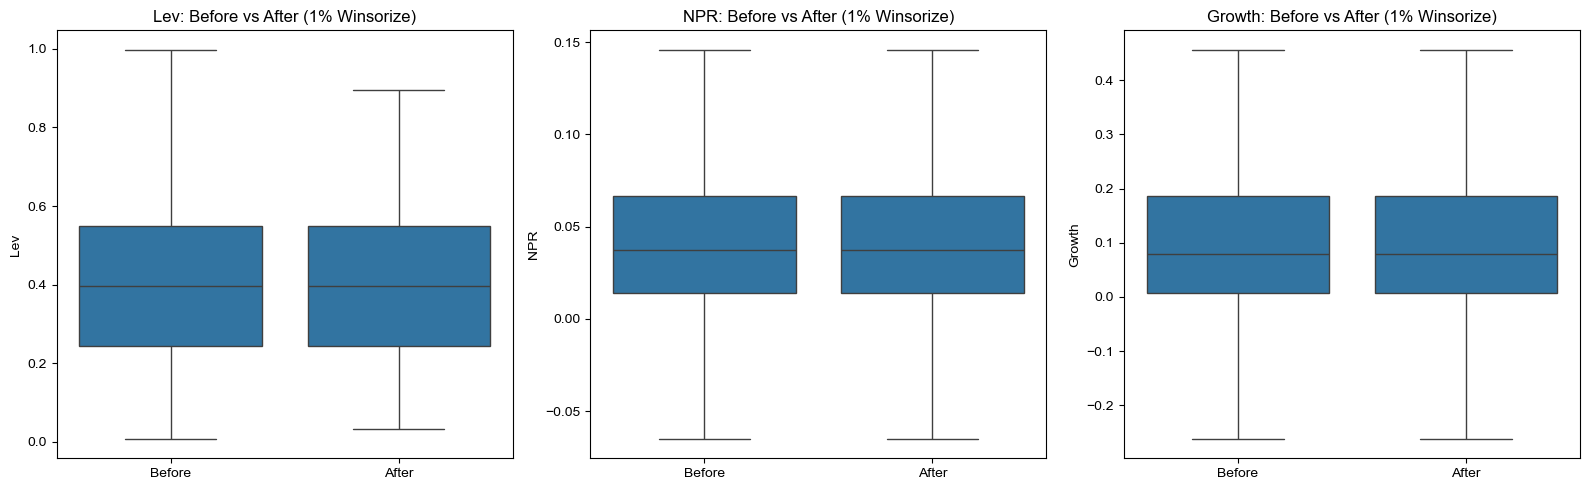

Saved: ../output/figures/Fig2_winsorize_boxplot_comparison.png
Saved: ../data/clean/panel_filtered_winsor_1_5.csv
Saved: ../data/clean/winsorize_summary_1_5.csv


In [22]:
# 绘制 Lev/NPR/Growth 的 Winsorize 前后箱型图对比
plot_vars = ['Lev', 'NPR', 'Growth']

plot_df = panel_w[['year']].copy()
for v in plot_vars:
    plot_df[f'{v}_before'] = panel_w[f'{v}_raw']
    plot_df[f'{v}_after'] = panel_w[v]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.set_style('whitegrid')

for i, v in enumerate(plot_vars):
    tmp = pd.DataFrame({
        'stage': np.where(panel_w.index >= 0, 'Before', 'Before'),
        'value': panel_w[f'{v}_raw']
    })
    tmp2 = pd.DataFrame({
        'stage': np.where(panel_w.index >= 0, 'After', 'After'),
        'value': panel_w[v]
    })
    tmp = pd.concat([tmp, tmp2], ignore_index=True)
    sns.boxplot(data=tmp, x='stage', y='value', ax=axes[i], showfliers=False)
    axes[i].set_title(f'{v}: Before vs After (1% Winsorize)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(v)

plt.tight_layout()

fig_dir = Path('../output/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / 'Fig2_winsorize_boxplot_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

# 导出 1.5 处理后的样本
panel_w.to_csv(CLEAN / 'panel_filtered_winsor_1_5.csv', index=False, encoding='utf-8-sig')
winsor_summary.to_csv(CLEAN / 'winsorize_summary_1_5.csv', index=False, encoding='utf-8-sig')

print('Saved:', fig_path)
print('Saved:', CLEAN / 'panel_filtered_winsor_1_5.csv')
print('Saved:', CLEAN / 'winsorize_summary_1_5.csv')